In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# ======================================================
# 1. LOAD DỮ LIỆU & CHUẨN BỊ
# ======================================================
# Đường dẫn file data đã làm sạch (nhớ kiểm tra lại đường dẫn máy bạn)
path_data = '../../data/processed/training_price_final.csv'

if not os.path.exists(path_data):
    print("❌ Lỗi: Không tìm thấy file dữ liệu!")
else:
    print("✅ Đã tìm thấy file dữ liệu.")

df = pd.read_csv(path_data, parse_dates=['Datetime'], index_col='Datetime')

# Chỉ lấy cột 'Gold' cho mô hình đơn biến
data = df[['Gold']].values

✅ Đã tìm thấy file dữ liệu.


In [4]:
# ======================================================
# 2. CHUẨN HÓA (SCALING)
# ======================================================
# LSTM rất nhạy cảm với biên độ, bắt buộc phải đưa về [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [5]:
# ======================================================
# 3. TẠO CỬA SỔ TRƯỢT (SLIDING WINDOW)
# ======================================================
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        # Lấy 60 giá trước đó làm Input (X)
        X.append(dataset[i:(i + time_step), 0])
        # Lấy giá ngay sau đó làm Output (y)
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

# Cấu hình: Nhìn lại 60 phút quá khứ để đoán phút tiếp theo
time_step = 60 
X, y = create_dataset(scaled_data, time_step)

# Reshape dữ liệu về dạng 3D [Samples, Time Steps, Features] để LSTM hiểu
# Features = 1 (vì chỉ có Gold)
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f"Kích thước dữ liệu đầu vào (X): {X.shape}")

Kích thước dữ liệu đầu vào (X): (177802, 60, 1)


In [6]:
# ======================================================
# 4. CHIA TRAIN / TEST
# ======================================================
# Time-series KHÔNG ĐƯỢC random shuffle. Cắt theo thời gian.
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [7]:
# ======================================================
# 5. XÂY DỰNG MÔ HÌNH LSTM
# ======================================================
model = Sequential()

# Layer 1: LSTM (return_sequences=True để nối tiếp layer sau)
model.add(LSTM(units=50, return_sequences=True, input_shape=(time_step, 1)))
model.add(Dropout(0.2)) # Tránh học tủ (Overfitting)

# Layer 2: LSTM
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Layer Output: 1 nơ-ron (Giá Gold dự đoán)
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

# ======================================================
# 6. HUẤN LUYỆN (TRAINING)
# ======================================================
# Dùng EarlyStopping: Nếu sau 5 vòng (patience=5) mà loss ko giảm thì dừng luôn cho nhanh
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("🚀 Bắt đầu huấn luyện...")
history = model.fit(
    X_train, y_train,
    epochs=50,           # Số vòng lặp tối đa
    batch_size=64,       # Học 64 mẫu cùng lúc (tăng tốc độ)
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)
print("✅ Huấn luyện hoàn tất!")

c:\Users\minam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🚀 Bắt đầu huấn luyện...
Epoch 1/50
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 195s 83ms/step - loss: 1.0183e-04 - val_loss: 1.4867e-04
Epoch 2/50
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 184s 75ms/step - loss: 6.9221e-06 - val_loss: 2.7337e-04
Epoch 3/50
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 181s 66ms/step - loss: 6.4402e-06 - val_loss: 1.0116e-04
Epoch 4/50
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 154s 69ms/step - loss: 6.2557e-06 - val_loss: 2.7959e-04
Epoch 5/50
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 189s 63ms/step - loss: 6.0280e-06 - val_loss: 1.8870e-04
Epoch 6/50
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 142s 63ms/step - loss: 5.8521e-06 - val_loss: 6.1644e-05
Epoch 7/50
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 142s 63ms/step - loss: 5.8009e-06 - val_loss: 0.0014
Epoch 8/50
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 144s 65ms/step - loss: 5.6266e-06 - val_loss: 6.9416e-04
Epoch 9/50
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 144s 65ms/step - loss: 5.4719e-06 - val_loss: 5.3947e-04
Epoch 10/50
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 210s 68ms/step - loss: 5.4260e-06 - val_loss: 

In [8]:
predictions = model.predict(X_test)
# 1. Load lại file dữ liệu GỐC
path_raw = '../../data/raw/data_price_realtime.csv' 
df_real_usd = pd.read_csv(path_raw)

# 2. Tạo một Scaler mới
real_price_scaler = MinMaxScaler(feature_range=(0, 1))
real_price_scaler.fit(df_real_usd[['Gold']]) 

# 3. Đảo ngược chuẩn hóa (FIX LỖI TẠI ĐÂY)
# Thêm .reshape(-1, 1) vào cả 2 biến để đảm bảo nó là mảng 2 chiều
pred_usd = real_price_scaler.inverse_transform(predictions.reshape(-1, 1))
actual_usd = real_price_scaler.inverse_transform(y_test.reshape(-1, 1)) # <--- Dòng này đã được sửa

# 4. Lưu lại kết quả chuẩn
test_dates = df.index[-len(actual_usd):]

result_df = pd.DataFrame({
    'Datetime': test_dates,
    'Actual': actual_usd.flatten(),     # Duỗi ra lại thành 1 chiều để lưu vào Excel
    'Predicted': pred_usd.flatten()
})

# Tạo folder và lưu file
import os
save_path = '../../results/predictions/LSTM.csv'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
result_df.to_csv(save_path, index=False)

print(f"\n✅ Đã lưu file kết quả (USD thật) tại: {save_path}")
print(result_df.tail())

1112/1112 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step

✅ Đã lưu file kết quả (USD thật) tại: ../../results/predictions/LSTM.csv
                 Datetime       Actual    Predicted
35556 2025-12-18 23:57:00  4357.509991  4351.085449
35557 2025-12-18 23:57:10  4358.511869  4351.040527
35558 2025-12-18 23:57:20  4359.573859  4351.081055
35559 2025-12-18 23:57:30  4360.004667  4351.286621
35560 2025-12-18 23:57:40  4360.004667  4351.609375


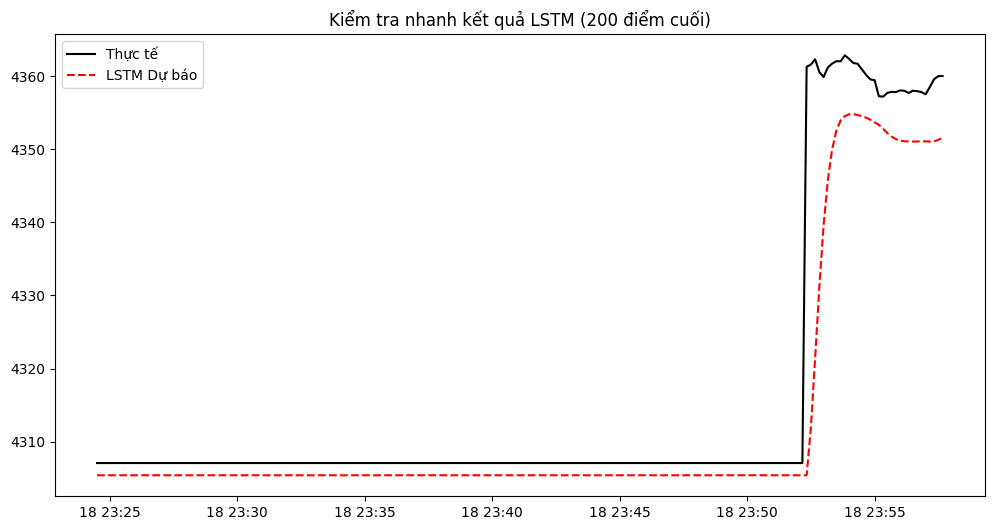

In [9]:
# ======================================================
# 9. VẼ BIỂU ĐỒ KIỂM TRA NHANH
# ======================================================
plt.figure(figsize=(12, 6))
# Chỉ vẽ 200 điểm cuối
plt.plot(result_df['Datetime'][-200:], result_df['Actual'][-200:], label='Thực tế', color='black')
plt.plot(result_df['Datetime'][-200:], result_df['Predicted'][-200:], label='LSTM Dự báo', color='red', linestyle='--')
plt.title('Kiểm tra nhanh kết quả LSTM (200 điểm cuối)')
plt.legend()
plt.show()